# Add pseudotime, pick terminal cell clusters, and make landscape embedding

Landscape embedding is built on landscape scaffold, that is created by picking terminal cell states and embedding them in 1D. 

The landscape can change drastically based on what scaffold is being used. 

This means that you should be happy with how your scaffold looks (all terminal cell types represented; not represented twice if there is no good reason for it), before expecting to get a good landscape.

In [1]:
import sys
import numpy as np
import anndata as ad

# Hack to get to src folder (this notebook is in notebooks/shared)
sys.path.insert(0, '..')

import src as scit
import anndata as ad

In [2]:
# Do landscape on the central, most connected celltypes. Disconnected cells are hard to embed on landscape

adata = ad.read_h5ad('private/data/marek/central.h5ad')

In [70]:
# Make pseudotime

scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=50)
g = scit.gr.neighbor_graph(adata)
scit.tl.diffmap(adata, g)

array([1.        , 0.99393874, 0.98715395, 0.9862671 , 0.98397374,
       0.98094356, 0.9754202 , 0.96503586, 0.95708084, 0.9511362 ,
       0.9475916 , 0.93967885, 0.9384827 , 0.93687415, 0.93140143],
      dtype=float32)

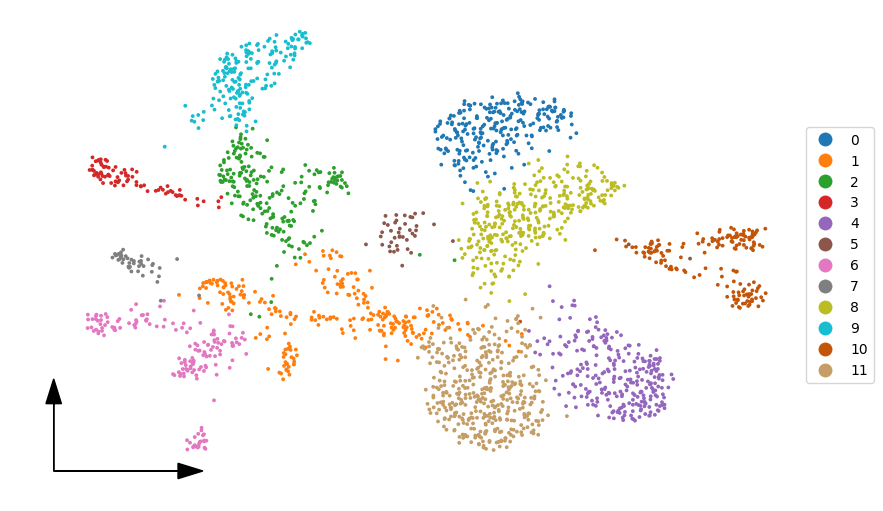

In [71]:
scit.gr.leiden(adata, g, 0.4, random_seed=10)
scit.pl.embedding2d(adata, 'X_umap', 'leiden', black_background=False)

In [72]:
import pandas as pd
# Merge into bigger clusters

d = {
    0: 0,
    8: 0,
    5: 0,
    10: 1,
    4: 2,
    11: 2,
    1: 3,
    2: 3,
    3: 3,
    6: 3,
    7: 3,
    9: 3
}

# These are the leiden clusters time will be normalized to
adata.obs['leiden'] = pd.Categorical([d[l] for l in adata.obs['leiden']])

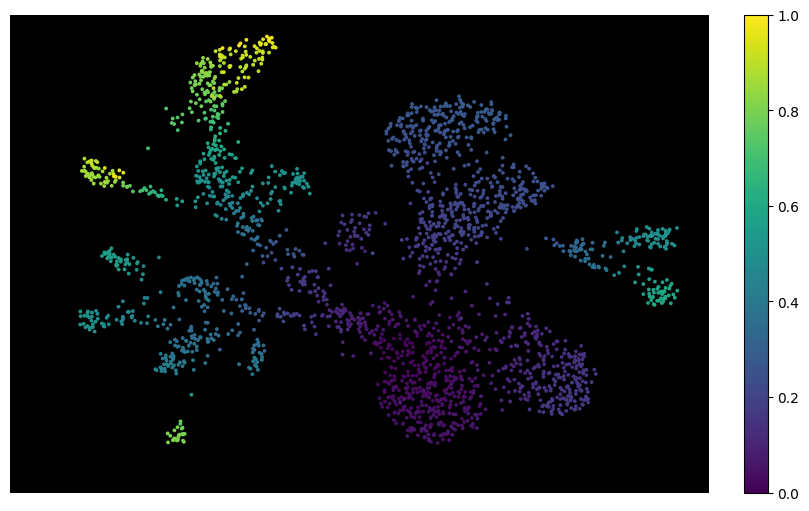

In [73]:
# pick id of "central" 0-timepoint cell
pid = 1060

scit.tl.diffusion_pseudotime(adata, pid)
scit.pl.embedding2d(adata, 'X_umap', 'dpt_pseudotime', black_background=True)

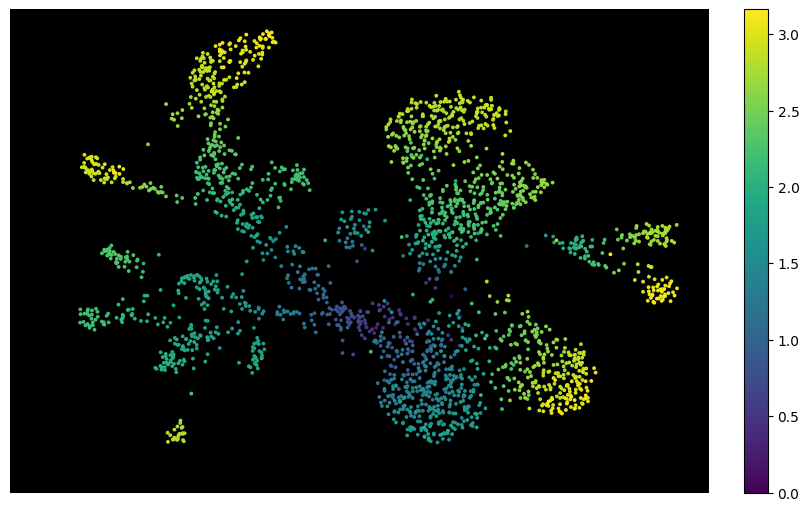

In [74]:
adata.obs['age'] = np.sqrt(10*scit.tl.normalize_time_per_cluster(adata, 'dpt_pseudotime', 'leiden'))
scit.pl.embedding2d(adata, 'X_umap', 'age', black_background=True)

In [75]:
# Use previously determined age if possible (not calculated using this package)

#adata.obs['age'] = ...

Text(0.5, 1.0, 'Pseudotime vs Age')

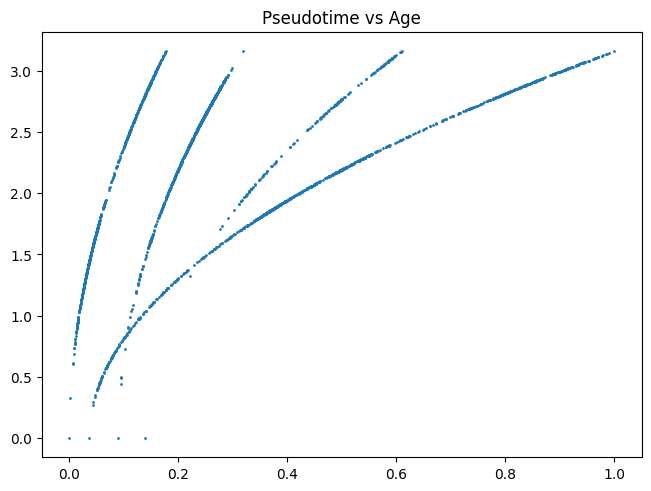

In [76]:
import matplotlib.pyplot as plt
plt.scatter(adata.obs['dpt_pseudotime'], adata.obs['age'], s=1)
plt.title('Pseudotime vs Age')

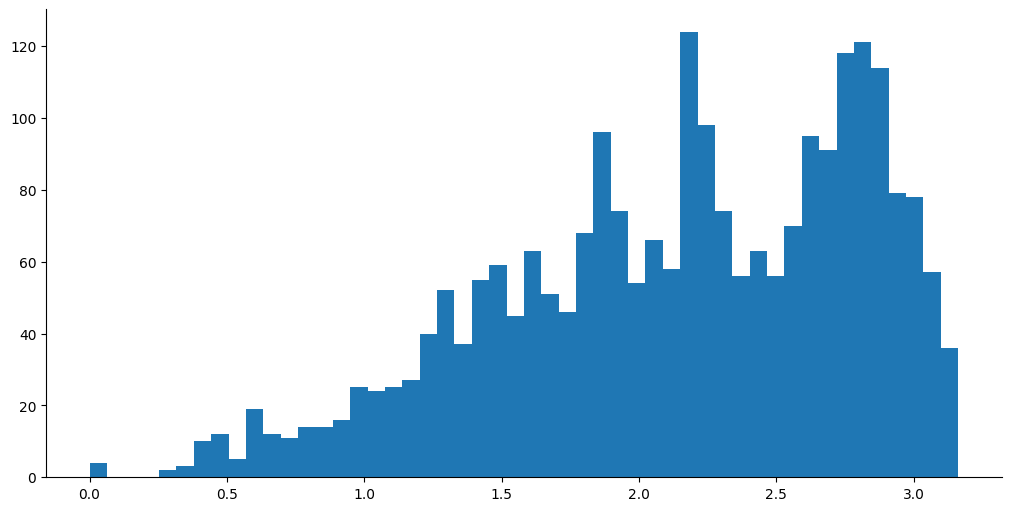

In [10]:
scit.pl.int.histogram(adata.obs['age'], bins=50)

In [104]:
# Create terminal scaffold

adata.obs['old_leiden'] = adata.obs['leiden']
sdata = adata[adata.obs['age'] > 2.5].copy()
scit.gr.knn(sdata, 'X_multi_spectral', n_neighbors=20)
sg = scit.gr.neighbor_graph(sdata)

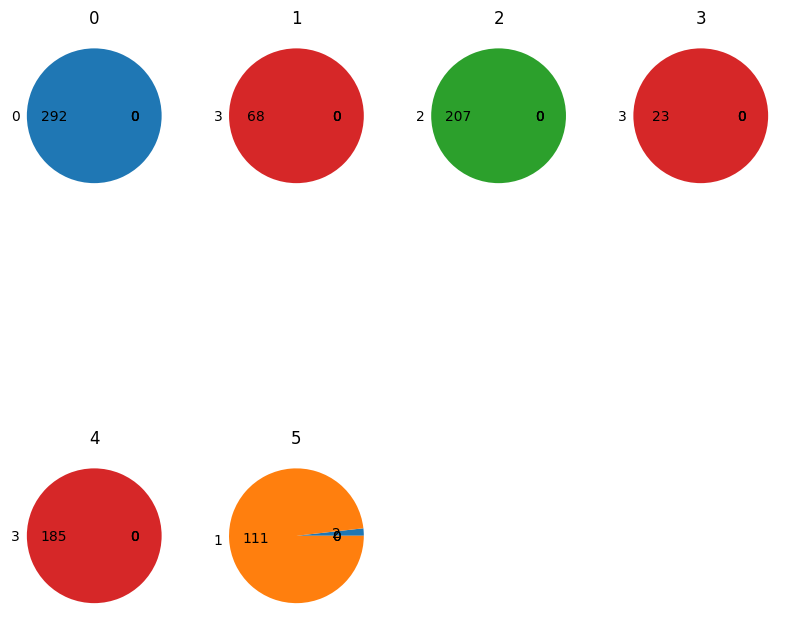

In [105]:
# Cluster and visualize scaffold

scit.gr.leiden(sdata, sg, resolution=0.1)
scit.set_defaults(figsize=(10,10))

# Visualize per-leiden-cluster contents
# Aim for representation of all categoricals and
# Not too much mixing 

scit.pl.compare_categorical(sdata, 'old_leiden', 'leiden', filter_min=0.1)

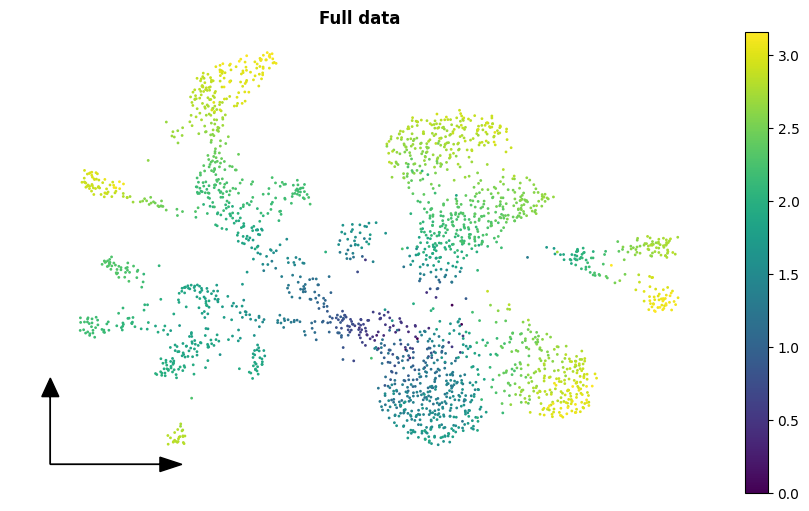

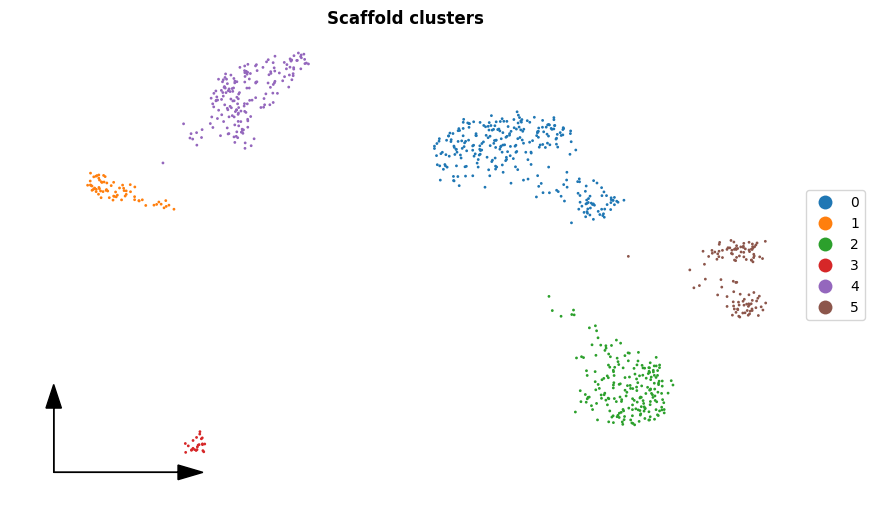

In [106]:
scit.set_defaults(figsize=(8,5))
scit.pl.embedding2d(adata, 'X_umap', 'age', size=1, alpha=1, title='Full data')
scit.pl.embedding2d(sdata, 'X_umap', 'leiden', size=1, title='Scaffold clusters')

In [107]:
# You can manually edit scaffold
sdata = sdata[~((sdata.obs['leiden'] == 3) + (sdata.obs['leiden'] == 1))]

/home/aleksander/Skrivbord/pyproject/notebooks/../src/graph/_neighbors.py:150: ImplicitModificationWarning: Setting element `.obsp['connectivities']` of view, initializing view as actual.
  adata.obsp['connectivities'] = _simplex_set.tocsr()
/home/aleksander/Skrivbord/pyproject/notebooks/../src/graph/_hierarchy.py:158: RuntimeWarning: divide by zero encountered in scalar divide
  [[_skip[i * 2], _skip[i * 2 + 1], 1 / _distances[i], msum[self.uq_membership + i]] for i in


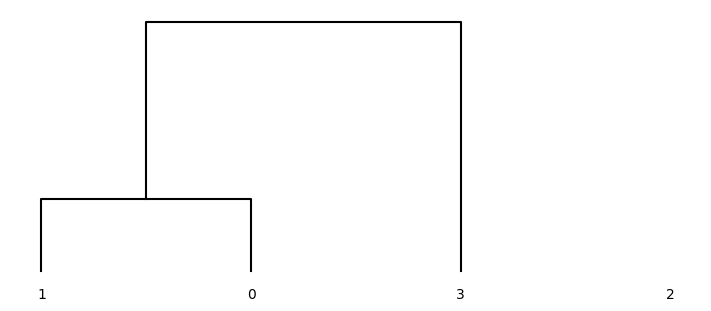

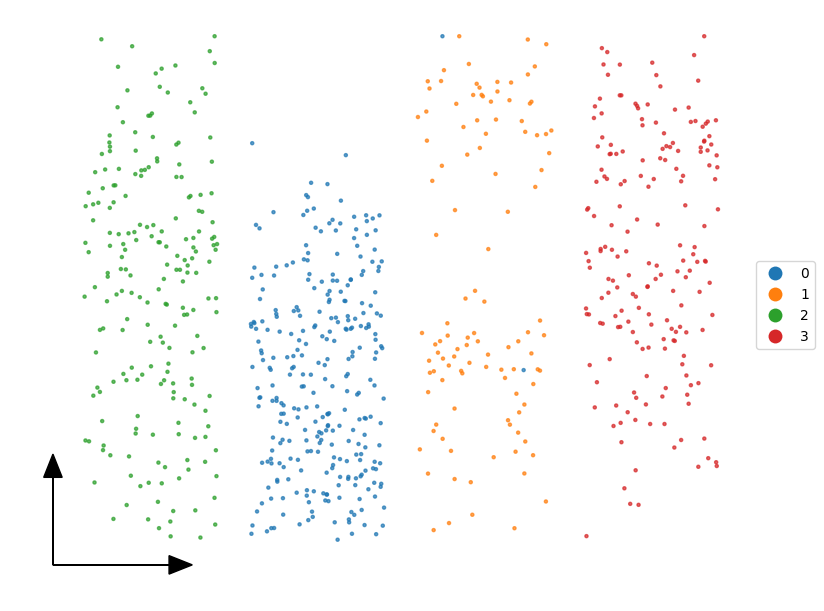

In [109]:
# Embed in 1D
scit.gr.knn(sdata, 'X_multi_spectral', n_neighbors=30)
sg = scit.gr.neighbor_graph(sdata)
scit.gr.community_hierarchy(sdata, sg, community_key='leiden')

scit.set_defaults(figsize=(7,3))
scit.adv.pl.community_dendrogram(sdata, negative_allowed=False)

scit.set_defaults(figsize=(7.5,6))

scit.em.dendrogram(sdata, 'age')
scit.pl.embedding2d(sdata, 'X_dendrogram', 'old_leiden', alpha=0.7, size=5)

In [110]:
scaffold = scit.adv.create_landscape_scaffold(sdata)
scaffold

Scaffold on 797 cells

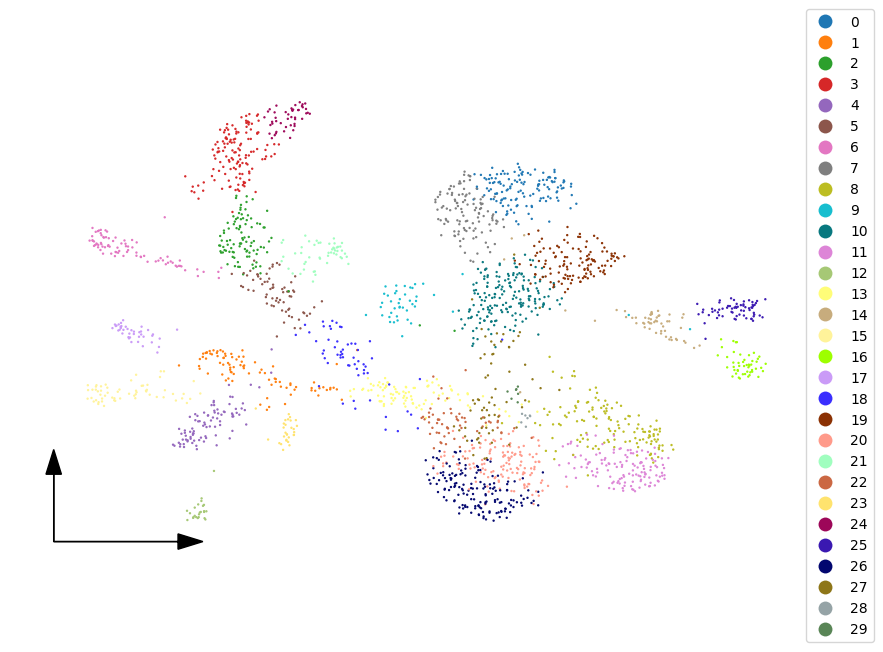

In [111]:
# Make metacells for coarse embedding
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=130)
g = scit.gr.neighbor_graph(adata)

scit.set_defaults(figsize=(8,5))
scit.gr.leiden(adata, g, 3.5)
scit.pl.embedding2d(adata, 'X_umap', 'leiden', size=0.5, alpha=1)

In [130]:
#rdata.obs_names_make_unique()
scit.em.landscape(
    adata,
    g,
    scaffold,
    'age',
    'X_multi_spectral', 
    return_coarse=True, 
    umap_epochs=10, # This should be lower if you have more cells
    umap_min_dist=0.1, # This should be higher if you have less cells
    umap_spread=1,
    y_mean_init=False,
    force_post_y=True
)

  0%|          | 0/9 [00:00<?, ?it/s]

Info: Creating layout using 4 leaf clusters


/home/aleksander/Skrivbord/pyproject/venv/lib/python3.12/site-packages/umap/umap_.py:2021: UserWarning: precomputed_knn[2] (knn_search_index) is not an NNDescent object: transforming new data with transform will be unavailable.
  warn(


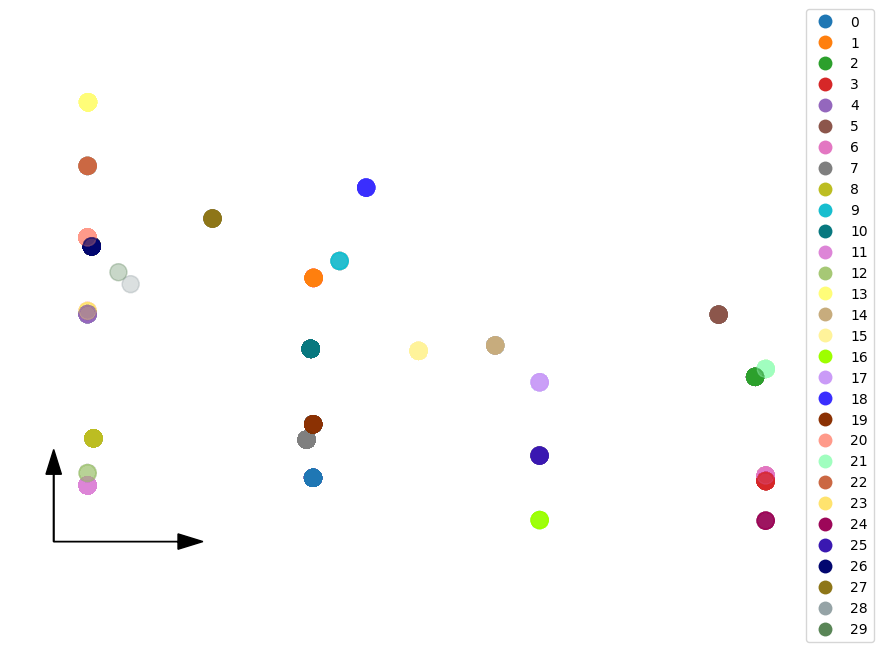

In [131]:
scit.pl.embedding2d(adata, 'X_coarse_landscape', 'leiden', size=150, alpha=0.05)

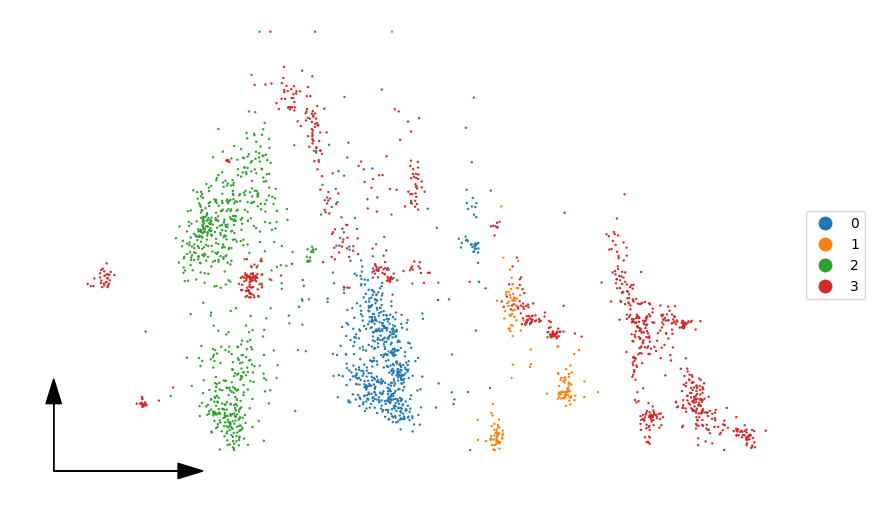

In [132]:
#del adata.obsm['X_coarse_landscape']
scit.pl.embedding2d(adata, 'X_landscape', 'old_leiden', size=0.5, alpha=1)

In [23]:
adata.write_h5ad('private/data/marek/central_landscape.h5ad')